In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

from neural_reconstruction.core.topology import TopologyBuilder
from neural_reconstruction.core.pathfinding import PathFinder
from neural_reconstruction.algorithms.fragment_linking.utils import compute_vector_angle,is_direction_too_similar
from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically

import skimage as ski
# from skimage.measure import label
from scipy.spatial import KDTree


In [2]:
BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID = 'S222-2_b'



In [3]:
image      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/image.png',       cv2.IMREAD_COLOR_RGB)[:, :, 1]  # 只取綠色通道
mask       = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/mask.png',        cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/weka.png',        cv2.IMREAD_GRAYSCALE)
label      = cv2.imread(f'{BASE_PATH}/{IMAGE_ID}/label.png',       cv2.IMREAD_GRAYSCALE)


In [4]:

roi_mask = dilate_epidermis_vertically(mask, offset_px=50)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
image = cv2.subtract(image, background)

roi_image = cv2.bitwise_and(image, image, mask=roi_mask)
roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

# apply opening to roi_annotation to remove small noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
# roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_OPEN, kernel)

# apply closing to roi_annotation to fill small holes
roi_annotation = cv2.morphologyEx(roi_annotation, cv2.MORPH_CLOSE, kernel, iterations=3)
roi_annotation[roi_annotation > 0] = 255


gt_builder = TopologyBuilder()
roi_label = cv2.bitwise_and(label, label, mask=roi_mask)
roi_label = cv2.morphologyEx(roi_label, cv2.MORPH_CLOSE, kernel, iterations=3)
gt_graph = gt_builder.build_seed_graph(roi_label)


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [5]:

annotation_component = np.asarray(ski.measure.label(roi_annotation, connectivity=2))

# 2. 骨架化 + 種子切分
topology_builder = TopologyBuilder(segment_length=3.0)
global_graph = topology_builder.build_seed_graph(roi_annotation, roi_image)

# 從 labeled image 補上 component_id
for node in global_graph.nodes():
    y, x = node
    global_graph.nodes[node]["component_id"] = int(annotation_component[int(y), int(x)])

# 元件內邊設低成本
for u, v, data in global_graph.edges(data=True):
    data["weight"] = 1e-5
# 3. 元件間路徑查找
cost_map = ((255 - roi_image.astype(np.float64)) / 255) ** 2


/home/pony/projects/ienf_q/src/neural_reconstruction/core/topology/topology_builder.py:125: VisibleDeprecationWarning: separator in column name will change to _ in version 0.13; to silence this warning, use `separator='-'` to maintain current behavior and use `separator='_'` to switch to the new default behavior.
  summary = summarize(skel_obj)


In [6]:
path_finder = PathFinder(cost_map)
topology_points = np.array(list(global_graph.nodes()))

kdtree = KDTree(topology_points)
seed_map = np.zeros_like(cost_map, dtype=bool)
for p in topology_points:
    seed_map[p[0], p[1]] = True

path_finder = PathFinder(cost_map)
topology_points = np.array(list(global_graph.nodes()))

path_lookup = path_finder.find_paths_from_seeds(
    topology_points=topology_points,
    kdtree=kdtree,
    search_radius=50,
    seed_map=seed_map,
    label_img=annotation_component,
)

In [7]:

# ============================================================
# Featurized Path Pair
# ============================================================
import pandas as pd
from neural_reconstruction.algorithms.fragment_linking.utils import (
    compute_fiber_orientation_field,
    get_point_orientation,
)

SIGMA = 2
orient_y, orient_x = compute_fiber_orientation_field(roi_image, sigma=SIGMA)

def get_orientation(pt):
    return get_point_orientation(orient_y, orient_x, pt)

print(f"Orientation field computed (sigma={SIGMA}). Shape: {orient_y.shape}")


Orientation field computed (sigma=2). Shape: (2053, 9433)


In [8]:

# ============================================================
# Feature extraction
# ============================================================

def extract_path_features(source, target, path, cost):
    """
    Group 1 – Cost features
        mean_cost   : cost / path_length  (average per-step cost)
        cost_std    : std of per-pixel cost_map values along path
        max_cost    : maximum per-pixel cost along path (darkest point)
        path_length : number of pixels in path

    Group 2 – Geometric features (Hessian-based local orientation)
        angle_A  : angle between fiber orientation at A and A→B direction [0,90]°
        angle_B  : angle between fiber orientation at B and B→A direction [0,90]°
        angle_AB : consistency of tangents at A and B – how "parallel" they are [0,90]°
                   0° = smooth curve, 90° = orientations are perpendicular
    """
    path_arr = np.array(path)
    path_length = len(path_arr)

    # --- Group 1: Cost features ---
    step_costs = cost_map[path_arr[:, 0], path_arr[:, 1]]
    mean_cost  = cost / path_length
    cost_std   = float(np.std(step_costs))
    max_cost   = float(np.max(step_costs))

    # --- Group 2: Geometric features ---
    o_A = get_orientation(source)   # local fiber direction at A
    o_B = get_orientation(target)   # local fiber direction at B

    # Connection direction A→B (unit vector)
    conn = np.array(target, dtype=float) - np.array(source, dtype=float)
    conn_unit = conn / (np.linalg.norm(conn) + 1e-10)

    # Tangent-connection angle: use abs(dot) because orientation is undirected
    def _angle_undirected(v, u):
        return float(np.degrees(np.arccos(np.clip(abs(np.dot(v, u)), 0.0, 1.0))))

    angle_A = _angle_undirected(o_A,  conn_unit)   # A's orientation vs A→B
    angle_B = _angle_undirected(o_B, -conn_unit)   # B's orientation vs B→A

    # Tangent consistency: align o_B to o_A's half-space, then measure angle
    o_B_aligned = o_B if np.dot(o_A, o_B) >= 0 else -o_B
    angle_AB = float(np.degrees(np.arccos(np.clip(np.dot(o_A, o_B_aligned), -1.0, 1.0))))

    return dict(
        source= source,
        target=target,
        original_cost=cost,
        mean_cost=mean_cost,
        cost_std=cost_std,
        max_cost=max_cost,
        path_length=path_length,
        angle_A=angle_A,
        angle_B=angle_B,
        angle_AB=angle_AB,
    )

# Build feature dataframe
records = []
seen = set()
for (source, target), (path, cost) in path_lookup.items():
    
    if (source, target) in seen or (target,source) in seen :
        continue  
    seen.add((source, target))
    feat = extract_path_features(source, target, path, cost)
    records.append(feat)

df = pd.DataFrame(records)
print(df[['mean_cost', 'cost_std', 'max_cost', 'path_length',
                            'angle_A', 'angle_B', 'angle_AB']].mean().T.to_string())


mean_cost       0.830233
cost_std        0.120826
max_cost        0.871442
path_length    30.639708
angle_A        46.175288
angle_B        50.704630
angle_AB       40.183156


In [9]:

composit_path = {}
for feat in records:
    # Normalized composite cost in [0, 1]:
    #   image evidence (mean + max cost) + geometric alignment (angle_A + angle_B)
    cost = (0.50 * feat['mean_cost']
            + 0.20 * feat['max_cost']
            + 0.20 * (feat['angle_A'] / 90.0)
            + 0.20 * (feat['angle_B'] / 90.0)
            + 0.10 * (feat['angle_AB'] / 90.0))  # Optional: add angle_AB for overall smoothness
    # cost = feat['original_cost']
    source, target = feat['source'], feat['target']
    path, _ = path_lookup[(source, target)]
    composit_path[(source, target)] = (path, cost)

print(f"Composite paths computed: {len(composit_path)}")
costs = [c for _, c in composit_path.values()]
print(f"Cost range: [{min(costs):.4f}, {max(costs):.4f}], mean={sum(costs)/len(costs):.4f}")


Composite paths computed: 4377
Cost range: [0.2158, 1.2276], mean=0.8493


In [10]:
from scipy.interpolate import interp1d

label_component = np.asarray(ski.measure.label(roi_label, connectivity=2))

valid_look_up = set()
invalid_look_up = set()
seen = set()
for (source, target), (path, cost) in composit_path.items():
    key = (min(source, target), max(source, target))
    if key in seen:
        continue
    seen.add(key)

    path_arr = np.array(path)
    middle = path_arr[1:-1]

    mostly_on_annotation = (
        len(middle) > 0 and
        np.mean(roi_label[middle[:, 0], middle[:, 1]] > 0) >= 0.9
    )
    same_component = (
        label_component[int(source[0]), int(source[1])] ==
        label_component[int(target[0]), int(target[1])]
    )

    if mostly_on_annotation and same_component:
        valid_look_up.add((source, target))
    else:
        invalid_look_up.add((source, target))

print(f"Valid paths:   {len(valid_look_up)}")
print(f"Invalid paths: {len(invalid_look_up)}")

Valid paths:   354
Invalid paths: 4023


Labelled paths  — valid: 354, invalid: 4023
Cost range      — min: 0.2158, max: 1.2276


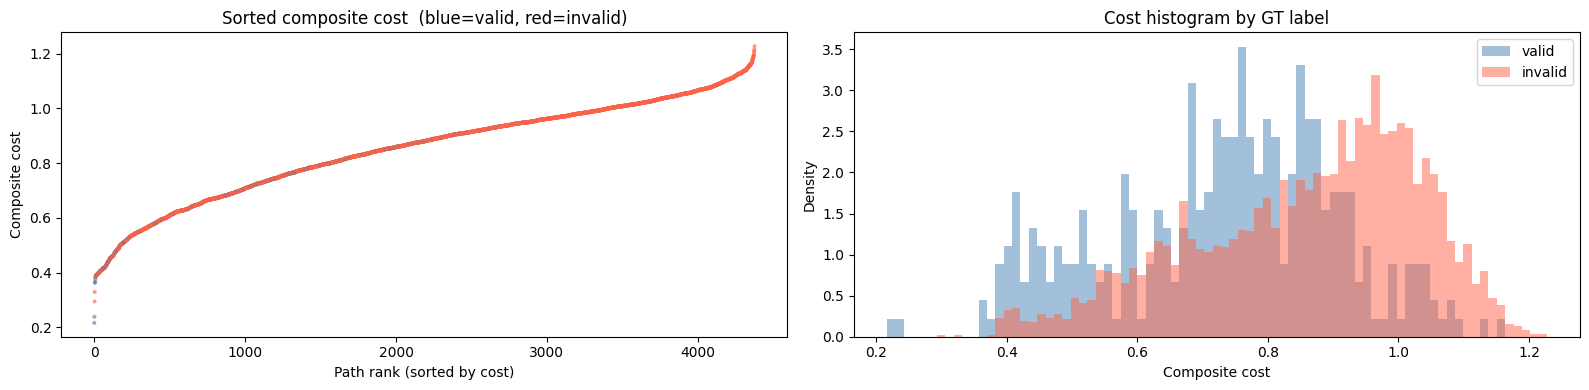

In [11]:

# ============================================================
# Build labelled cost array
# ============================================================
cost_records = []
for (source, target), (path, cost) in composit_path.items():
    if (source, target) in valid_look_up:
        label = 1          # valid (same GT component, path on annotation)
    elif (source, target) in invalid_look_up:
        label = 0          # invalid
    else:
        continue           # unlabelled — skip
    cost_records.append({'source': source, 'target': target, 'cost': cost, 'label': label})

df_cost = pd.DataFrame(cost_records).sort_values('cost').reset_index(drop=True)
costs_valid   = df_cost.loc[df_cost['label'] == 1, 'cost'].values
costs_invalid = df_cost.loc[df_cost['label'] == 0, 'cost'].values
all_costs     = df_cost['cost'].values

print(f"Labelled paths  — valid: {len(costs_valid)}, invalid: {len(costs_invalid)}")
print(f"Cost range      — min: {all_costs.min():.4f}, max: {all_costs.max():.4f}")

# ── Sorted cost plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
colors = np.where(df_cost['label'] == 1, 'steelblue', 'tomato')
ax.scatter(df_cost.index, df_cost['cost'], c=colors, s=4, alpha=0.5)
ax.set_xlabel("Path rank (sorted by cost)")
ax.set_ylabel("Composite cost")
ax.set_title("Sorted composite cost  (blue=valid, red=invalid)")

# ── Histogram ─────────────────────────────────────────────────────────────────
ax = axes[1]
bins = np.linspace(all_costs.min(), all_costs.max(), 80)
ax.hist(costs_valid,   bins=bins, alpha=0.5, color='steelblue', label='valid',   density=True)
ax.hist(costs_invalid, bins=bins, alpha=0.5, color='tomato',    label='invalid',  density=True)
ax.set_xlabel("Composite cost")
ax.set_ylabel("Density")
ax.set_title("Cost histogram by GT label")
ax.legend()

plt.tight_layout()
plt.show()


GMM fit (2 components, sorted by mean):
  Component 0: weight=0.381,  mean=0.6726,  std=0.1317
  Component 1: weight=0.619,  mean=0.9583,  std=0.0971

Otsu threshold: 0.8070


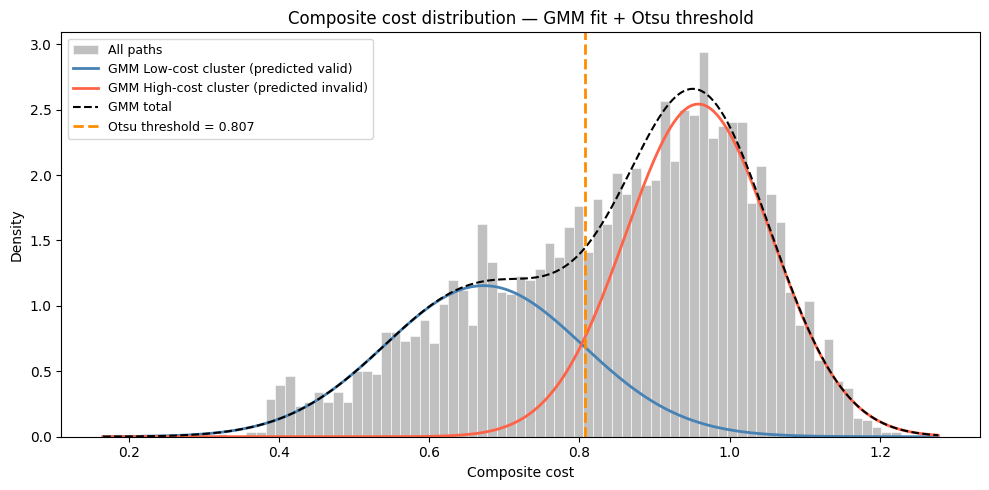

In [12]:

# ============================================================
# Gaussian Mixture (2 components) fit  +  Otsu threshold
# ============================================================
from sklearn.mixture import GaussianMixture
from skimage.filters import threshold_otsu
from scipy.stats import norm

# --- Fit 2-component GMM ---
gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(all_costs.reshape(-1, 1))

# Sort components by mean so component-0 = lower cost = "valid" cluster
order      = np.argsort(gmm.means_.ravel())
means      = gmm.means_.ravel()[order]
stds       = np.sqrt(gmm.covariances_.ravel())[order]
weights    = gmm.weights_[order]

print("GMM fit (2 components, sorted by mean):")
for i, (w, mu, sigma) in enumerate(zip(weights, means, stds)):
    print(f"  Component {i}: weight={w:.3f},  mean={mu:.4f},  std={sigma:.4f}")

# --- Otsu threshold on the full cost distribution ---
# Discretise to [0, 255] for skimage's threshold_otsu
cost_min, cost_max = all_costs.min(), all_costs.max()
cost_uint8 = ((all_costs - cost_min) / (cost_max - cost_min) * 255).astype(np.uint8)
otsu_uint8 = threshold_otsu(cost_uint8)
otsu_thresh = otsu_uint8 / 255.0 * (cost_max - cost_min) + cost_min
print(f"\nOtsu threshold: {otsu_thresh:.4f}")

# --- Visualise ---
x = np.linspace(cost_min - 0.05, cost_max + 0.05, 500)
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(cost_min, cost_max, 80)
ax.hist(all_costs, bins=bins, density=True, color='silver', edgecolor='white',
        linewidth=0.4, label='All paths')

colors_gmm = ['steelblue', 'tomato']
labels_gmm = ['Low-cost cluster (predicted valid)', 'High-cost cluster (predicted invalid)']
for i, (w, mu, sigma, c, lbl) in enumerate(zip(weights, means, stds, colors_gmm, labels_gmm)):
    ax.plot(x, w * norm.pdf(x, mu, sigma), color=c, linewidth=2, label=f'GMM {lbl}')

total_pdf = sum(w * norm.pdf(x, mu, sigma) for w, mu, sigma in zip(weights, means, stds))
ax.plot(x, total_pdf, 'k--', linewidth=1.5, label='GMM total')

ax.axvline(otsu_thresh, color='darkorange', linewidth=2, linestyle='--',
           label=f'Otsu threshold = {otsu_thresh:.3f}')

ax.set_xlabel("Composite cost")
ax.set_ylabel("Density")
ax.set_title("Composite cost distribution — GMM fit + Otsu threshold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Otsu threshold : 0.8070
Total labelled : 4377  (valid=354, invalid=4023)

Confusion matrix  (rows=GT, cols=Pred):
                  Pred valid   Pred invalid
  GT valid               227            127
  GT invalid            1386           2637

Accuracy   : 65.4%
Precision  : 14.1%   (of paths predicted valid, how many truly are)
Recall     : 64.1%   (of truly valid paths, how many we catch)
F1 score   : 0.231


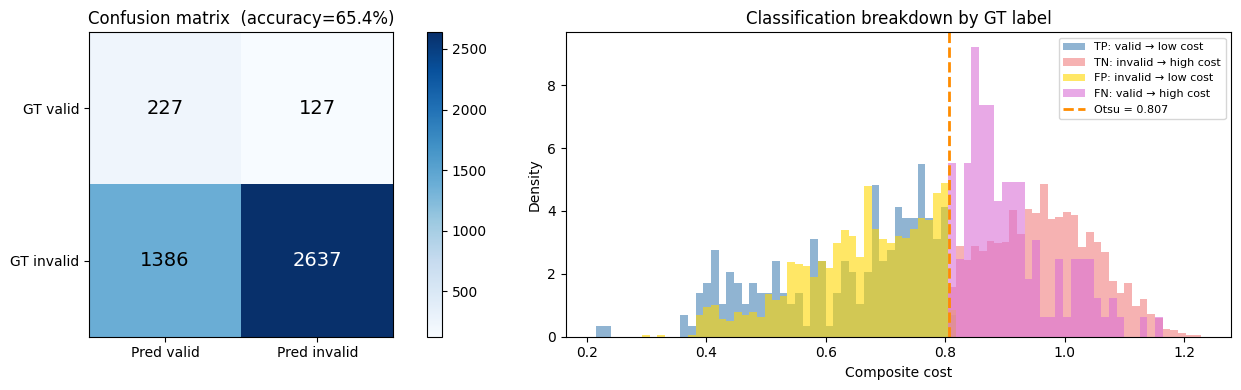

In [13]:

# ============================================================
# Otsu classification accuracy
# Assumption: cost < otsu_thresh → predicted valid  (label = 1)
#             cost >= otsu_thresh → predicted invalid (label = 0)
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report

gt_labels   = df_cost['label'].values          # 1=valid, 0=invalid
pred_labels = (df_cost['cost'].values < otsu_thresh).astype(int)

cm = confusion_matrix(gt_labels, pred_labels, labels=[1, 0])
tn, fp, fn, tp = cm[1, 1], cm[1, 0], cm[0, 1], cm[0, 0]   # relative to "invalid=0"

# Restate in plain terms
# pred=1 (low cost) / pred=0 (high cost)
# gt=1 (valid)      / gt=0 (invalid)
tp_valid   = int(np.sum((gt_labels == 1) & (pred_labels == 1)))   # valid   → low cost  ✓
fp_invalid = int(np.sum((gt_labels == 0) & (pred_labels == 1)))   # invalid → low cost  ✗ (FP)
fn_valid   = int(np.sum((gt_labels == 1) & (pred_labels == 0)))   # valid   → high cost ✗ (FN)
tn_invalid = int(np.sum((gt_labels == 0) & (pred_labels == 0)))   # invalid → high cost ✓

total   = len(gt_labels)
acc     = (tp_valid + tn_invalid) / total
prec    = tp_valid / (tp_valid + fp_invalid + 1e-9)
recall  = tp_valid / (tp_valid + fn_valid   + 1e-9)
f1      = 2 * prec * recall / (prec + recall + 1e-9)

print(f"Otsu threshold : {otsu_thresh:.4f}")
print(f"Total labelled : {total}  (valid={len(costs_valid)}, invalid={len(costs_invalid)})")
print()
print("Confusion matrix  (rows=GT, cols=Pred):")
print(f"                  Pred valid   Pred invalid")
print(f"  GT valid        {tp_valid:>10}   {fn_valid:>12}")
print(f"  GT invalid      {fp_invalid:>10}   {tn_invalid:>12}")
print()
print(f"Accuracy   : {acc*100:.1f}%")
print(f"Precision  : {prec*100:.1f}%   (of paths predicted valid, how many truly are)")
print(f"Recall     : {recall*100:.1f}%   (of truly valid paths, how many we catch)")
print(f"F1 score   : {f1:.3f}")

# ── Visualise confusion matrix ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confusion matrix heatmap
cm_display = np.array([[tp_valid, fn_valid], [fp_invalid, tn_invalid]])
im = axes[0].imshow(cm_display, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Pred valid', 'Pred invalid'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['GT valid', 'GT invalid'])
axes[0].set_title(f"Confusion matrix  (accuracy={acc*100:.1f}%)")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_display[i, j]),
                     ha='center', va='center', fontsize=14,
                     color='white' if cm_display[i, j] > cm_display.max() * 0.6 else 'black')
plt.colorbar(im, ax=axes[0])

# Cost distribution coloured by correctness
axes[1].hist(df_cost.loc[(df_cost['label']==1) & (pred_labels==1), 'cost'],
             bins=bins, alpha=0.6, color='steelblue', label='TP: valid → low cost', density=True)
axes[1].hist(df_cost.loc[(df_cost['label']==0) & (pred_labels==0), 'cost'],
             bins=bins, alpha=0.6, color='lightcoral', label='TN: invalid → high cost', density=True)
axes[1].hist(df_cost.loc[(df_cost['label']==0) & (pred_labels==1), 'cost'],
             bins=bins, alpha=0.6, color='gold',      label='FP: invalid → low cost', density=True)
axes[1].hist(df_cost.loc[(df_cost['label']==1) & (pred_labels==0), 'cost'],
             bins=bins, alpha=0.6, color='orchid',    label='FN: valid → high cost',  density=True)
axes[1].axvline(otsu_thresh, color='darkorange', linewidth=2, linestyle='--',
                label=f'Otsu = {otsu_thresh:.3f}')
axes[1].set_xlabel("Composite cost")
axes[1].set_ylabel("Density")
axes[1].set_title("Classification breakdown by GT label")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


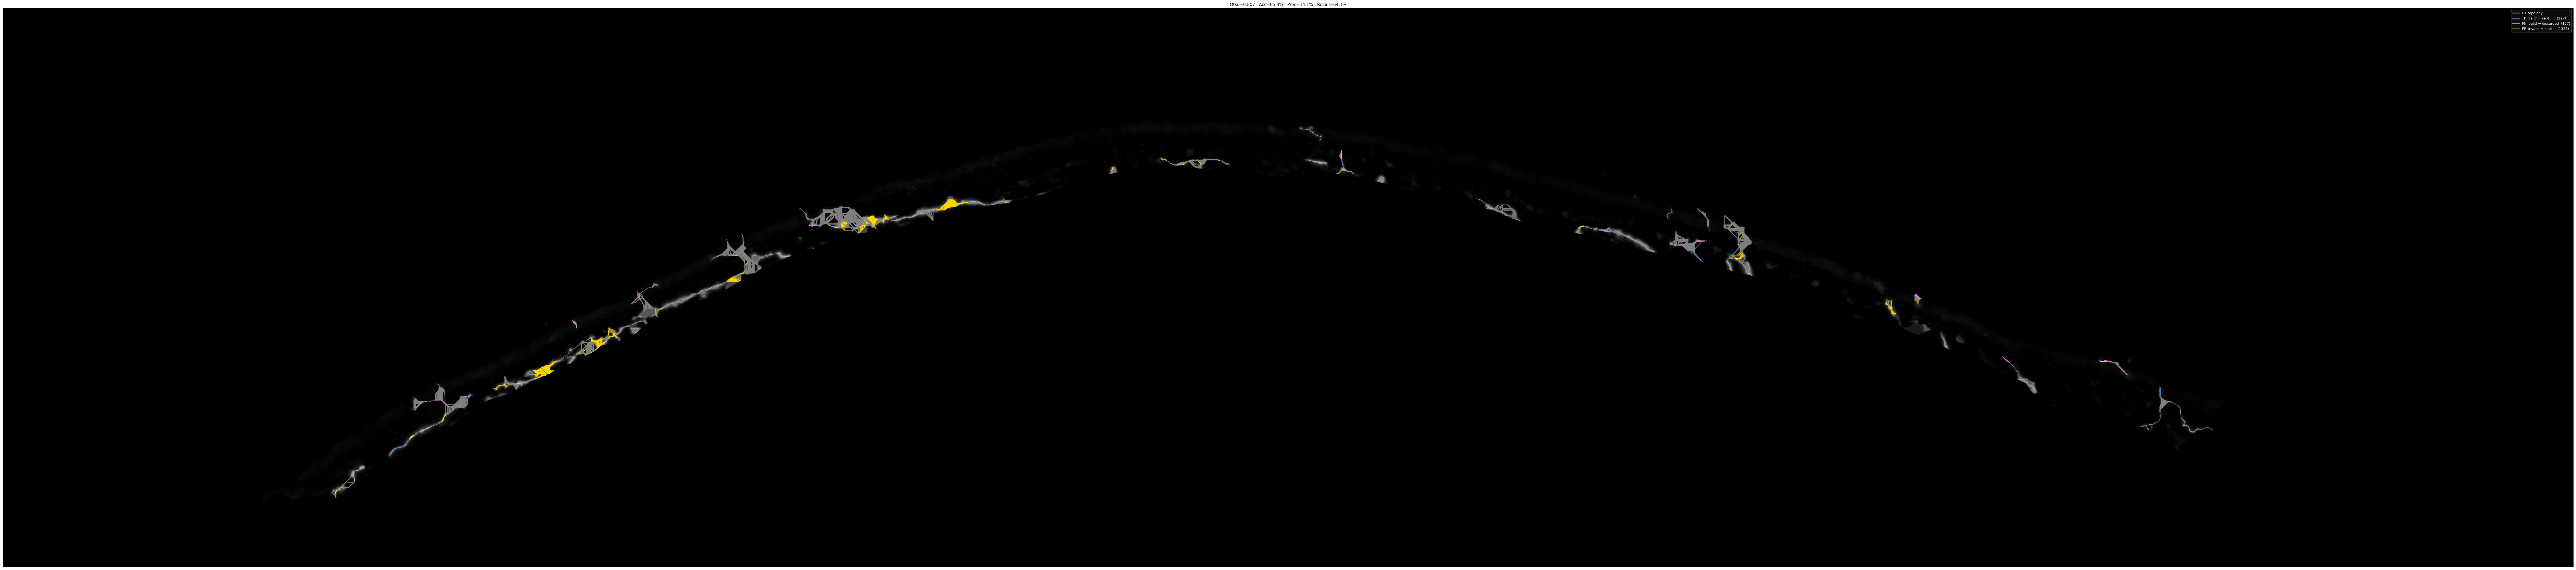

In [14]:

# ============================================================
# Visualise Otsu filtering results overlaid on GT image
#   GT topology (white, dim)  — reference
#   TP  valid   → kept        — steelblue
#   FN  valid   → discarded   — orchid
#   FP  invalid → kept        — gold
#   TN  invalid → discarded   — not drawn (correctly rejected)
# ============================================================

def _get_path(data, u, v):
    for key in ('path', 'path-coordinates'):
        p = data.get(key)
        if p is not None:
            return p
    return [u, v]

def _draw_path(ax, path, color, lw=1.5, alpha=0.85):
    if len(path) < 2:
        return
    ys = [p[0] for p in path]
    xs = [p[1] for p in path]
    ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha, solid_capstyle='round')


fig_size = 96
fig, ax = plt.subplots(figsize=(fig_size,
                                fig_size * roi_image.shape[0]/roi_image.shape[1]))

ax.imshow(roi_image, cmap='gray', vmin=0, vmax=255)

# GT topology — white, thin, semi-transparent
for u, v, data in gt_graph.edges(data=True):
    _draw_path(ax, _get_path(data, u, v), color='white', lw=1.0, alpha=0.4)

# Merge pred_labels back into df_cost for row-wise lookup
df_cost['pred'] = pred_labels

for _, row in df_cost.iterrows():
    src, tgt = row['source'], row['target']
    key = (src, tgt) if (src, tgt) in composit_path else (tgt, src)
    if key not in composit_path:
        continue
    path, _ = composit_path[key]

    gt, pred = int(row['label']), int(row['pred'])
    if   gt == 1 and pred == 1:
        _draw_path(ax, path, color='steelblue', lw=1.8)   # TP
    elif gt == 1 and pred == 0:
        _draw_path(ax, path, color='orchid',    lw=1.8)   # FN
    elif gt == 0 and pred == 1:
        _draw_path(ax, path, color='gold',      lw=1.8)   # FP
    elif gt == 0 and pred == 0:
        _draw_path(ax, path, color='gray',      lw=1.8)   # TN
    # TN: not drawn

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color='white',     linewidth=2, label='GT topology'),
    Line2D([0], [0], color='steelblue', linewidth=2, label=f'TP  valid → kept       ({tp_valid})'),
    Line2D([0], [0], color='orchid',    linewidth=2, label=f'FN  valid → discarded  ({fn_valid})'),
    Line2D([0], [0], color='gold',      linewidth=2, label=f'FP  invalid → kept     ({fp_invalid})'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9,
          framealpha=0.75, facecolor='#111111', labelcolor='white')
ax.set_title(
    f"Otsu={otsu_thresh:.3f}   Acc={acc*100:.1f}%   "
    f"Prec={prec*100:.1f}%   Recall={recall*100:.1f}%",
    fontsize=11,
)
ax.axis('off')
plt.tight_layout()
plt.show()


In [15]:

# ============================================================
# 確認篩選後保留的連接 (pred=1) 是否都在同一 label_component 內
# ============================================================
kept_rows = df_cost[df_cost['pred'] == 1]

same_comp_kept   = 0
cross_comp_kept  = 0
cross_comp_examples = []

for _, row in kept_rows.iterrows():
    src, tgt = row['source'], row['target']
    c_src = label_component[int(src[0]), int(src[1])]
    c_tgt = label_component[int(tgt[0]), int(tgt[1])]

    if c_src == c_tgt:
        same_comp_kept += 1
    else:
        cross_comp_kept += 1
        if len(cross_comp_examples) < 5:
            cross_comp_examples.append((src, tgt, c_src, c_tgt, row['cost']))

total_kept = len(kept_rows)
print(f"保留路徑總數 (pred=1)      : {total_kept}")
print(f"  同一 label_component    : {same_comp_kept}  ({same_comp_kept/total_kept*100:.1f}%)")
print(f"  跨   label_component    : {cross_comp_kept}  ({cross_comp_kept/total_kept*100:.1f}%)")

if cross_comp_examples:
    print(f"\n跨 component 範例 (最多 5 筆):")
    print(f"  {'source':>20}  {'target':>20}  {'comp_src':>8}  {'comp_tgt':>8}  {'cost':>7}")
    for src, tgt, cs, ct, cost in cross_comp_examples:
        print(f"  {str(src):>20}  {str(tgt):>20}  {cs:>8}  {ct:>8}  {cost:>7.4f}")
else:
    print("\n✓ 所有保留連接都在同一 label_component 內，無跨 component 連接。")


保留路徑總數 (pred=1)      : 1613
  同一 label_component    : 600  (37.2%)
  跨   label_component    : 1013  (62.8%)

跨 component 範例 (最多 5 筆):
                source                target  comp_src  comp_tgt     cost
          (1338, 2009)          (1340, 2002)         0        40   0.3845
          (1358, 1956)          (1341, 1996)        33        40   0.3895
          (1338, 2009)          (1342, 1994)         0        40   0.3915
          (1338, 2009)          (1340, 2006)         0        40   0.3918
          (1338, 2009)          (1341, 1999)         0        40   0.3919
